In [1]:
import pandas as pd


democrats_raw_path = '/Users/kimminseo/Documents/UCPH/ISP/dataset/reddit_opinion_democrats_raw.csv'
republicans_raw_path = '/Users/kimminseo/Documents/UCPH/ISP/dataset/reddit_opinion_republican_raw.csv'

democrats_df = pd.read_csv(democrats_raw_path)
republicans_df = pd.read_csv(republicans_raw_path)


print("Democrats - top 5 rows:")
print(democrats_df.head(5))
print("\nRepublicans - top 5 rows:")
print(republicans_df.head(5))

FileNotFoundError: [Errno 2] No such file or directory: '/Users/kimminseo/Documents/UCPH/ISP/dataset/reddit_opinion_democrats_raw.csv'

Plot saved successfully to: /Users/kimminseo/Documents/UCPH/ISP/dataset/post_volume_2023_recent.png


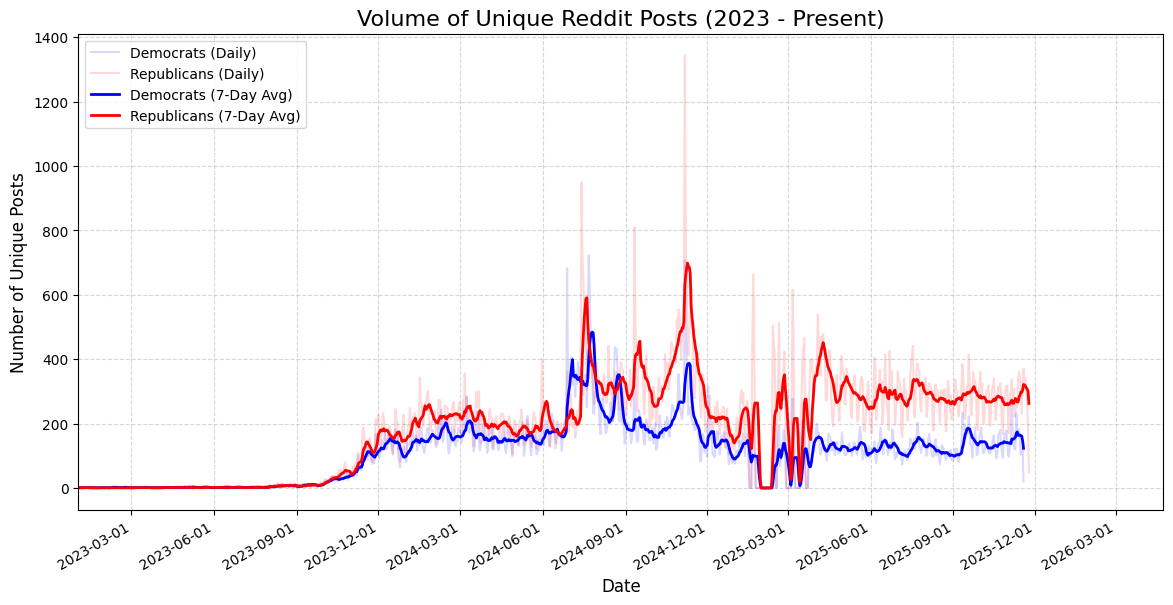

In [ ]:
# Post Volume Visualization (2023 - Recent)

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import os


democrats_df['post_created_time'] = pd.to_datetime(democrats_df['post_created_time'], errors='coerce')
republicans_df['post_created_time'] = pd.to_datetime(republicans_df['post_created_time'], errors='coerce')

dem_daily = democrats_df.groupby(pd.Grouper(key='post_created_time', freq='D'))['post_id'].nunique()
rep_daily = republicans_df.groupby(pd.Grouper(key='post_created_time', freq='D'))['post_id'].nunique()


plt.figure(figsize=(14, 7))

plt.plot(dem_daily.index, dem_daily, color='blue', alpha=0.15, label='Democrats (Daily)')
plt.plot(rep_daily.index, rep_daily, color='red', alpha=0.15, label='Republicans (Daily)')
start_date = pd.Timestamp('2023-01-01')
plt.xlim(left=start_date)

plt.title('Volume of Unique Reddit Posts (2023 - Present)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Unique Posts', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gcf().autofmt_xdate()

output_path = '/Users/kimminseo/Documents/UCPH/ISP/dataset/postvolume_centered.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Plot saved successfully to: {output_path}")

plt.show()

In [ ]:
# Cut raw data from 2023-09-01 to 2025-09-30

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

start_date = '2023-09-01'
end_date = '2025-09-30'

democrats_df['post_created_time'] = pd.to_datetime(democrats_df['post_created_time'], errors='coerce')
republicans_df['post_created_time'] = pd.to_datetime(republicans_df['post_created_time'], errors='coerce')

mask_dem = (democrats_df['post_created_time'] >= start_date) & (democrats_df['post_created_time'] <= end_date)
mask_rep = (republicans_df['post_created_time'] >= start_date) & (republicans_df['post_created_time'] <= end_date)

dem_filtered = democrats_df.loc[mask_dem].copy()
rep_filtered = republicans_df.loc[mask_rep].copy()

print(f"Democrats filtered rows: {len(dem_filtered)}")
print(f"Republicans filtered rows: {len(rep_filtered)}")

base_path = '/Users/kimminseo/Documents/UCPH/ISP/dataset'

dem_output_csv = os.path.join(base_path, 'reddit_democrats.csv')
rep_output_csv = os.path.join(base_path, 'reddit_republican.csv')

dem_filtered.to_csv(dem_output_csv, index=False)
rep_filtered.to_csv(rep_output_csv, index=False)

print(f"Saved filtered CSVs to:\n  - {dem_output_csv}\n  - {rep_output_csv}")


In [4]:
# Count rows in dem_df and rep_df (load CSVs if variables not in memory)

sup_df = pd.read_csv('/Users/kimminseo/Documents/UCPH/ISP/dataset/superuser_with_scores.csv')
sup_rows = len(sup_df)

print(f"superuser rows: {sup_rows:,}")


superuser rows: 309,956


In [ ]:
# Gemini Helped Data Inspection

import pandas as pd

# Load your dataframes first if they aren't in memory
dem_df = pd.read_csv('/Users/kimminseo/Documents/UCPH/ISP/dataset/reddit_democrats.csv')
rep_df = pd.read_csv('/Users/kimminseo/Documents/UCPH/ISP/dataset/reddit_republican.csv')

def deep_inspect(df, name):
    print(f"\n===== DEEP DIVE REPORT: {name} =====")
    
    # 1. EXACT TEXT DUPLICATES (Spam / Bot Copypasta)
    # If the exact same sentence appears 10,000 times, it's likely a bot.
    duplicate_count = df.duplicated(subset=['self_text']).sum()
    print(f"1. Duplicate Comments (Exact text match): {duplicate_count:,} rows")
    
    if duplicate_count > 0:
        print("   Top 3 most repeated comments:")
        print(df['self_text'].value_counts().head(3).to_string())

    # 2. "GHOST" STRINGS
    # Strings that are technically text but meaningless for NLP
    ghosts = ['nan', 'null', 'deleted', 'removed', '.', '?', '']
    # Convert to string to avoid errors, then lower()
    mask_ghost = df['self_text'].astype(str).str.lower().str.strip().isin(ghosts)
    print(f"\n2. Hidden 'Ghost' Strings ('nan', '.', '?'): {mask_ghost.sum()} rows")

    # 3. MICRO-COMMENTS (Noise)
    # Comments shorter than 5 characters (e.g., "lol", "This")
    # We force convert to str first to handle any mixed types
    mask_short = df['self_text'].astype(str).str.len() < 5
    print(f"3. Short Comments (<5 chars): {mask_short.sum()} rows")
    
    # 4. SUPER USERS (Potential Bots)
    # Users who account for a suspicious % of the total volume
    top_user = df['author_name'].value_counts().iloc[0]
    top_user_name = df['author_name'].value_counts().index[0]
    print(f"\n4. Most Active User: '{top_user_name}' with {top_user:,} posts")

    # 5. DATA TYPES
    # Check if 'score' or 'ups' contains non-numbers (mixed types error)
    # (Just a quick check on one numeric column)
    if 'score' in df.columns:
        non_numeric = pd.to_numeric(df['score'], errors='coerce').isnull().sum()
        print(f"5. Rows with Invalid (Non-Numeric) Scores: {non_numeric}")

    print("==========================================")

# Run the deep dive
deep_inspect(dem_df, "DEMOCRATS")
deep_inspect(rep_df, "REPUBLICANS")

/var/folders/tq/pmn07sd93gs_hl4cdhsww3qh0000gn/T/ipykernel_1690/246354752.py:4: DtypeWarning: Columns (1,8,9,10,16,17,21) have mixed types. Specify dtype option on import or set low_memory=False.
  dem_df = pd.read_csv('/Users/kimminseo/Documents/UCPH/ISP/dataset/reddit_democrats.csv')
/var/folders/tq/pmn07sd93gs_hl4cdhsww3qh0000gn/T/ipykernel_1690/246354752.py:5: DtypeWarning: Columns (1,8,9,10,17,21) have mixed types. Specify dtype option on import or set low_memory=False.
  rep_df = pd.read_csv('/Users/kimminseo/Documents/UCPH/ISP/dataset/reddit_republican.csv')



===== DEEP DIVE REPORT: DEMOCRATS =====
1. Duplicate Comments (Exact text match): 139,542 rows
   Top 3 most repeated comments:
self_text
SS: This post attempts to compile the various conspiracy explanations for chemtrails.  I'm no expert on this but this is just stuff I've heard here and there.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [ ]:

# Duplicate Detection

def spy_on_system_messages(df, name):
    print(f"\n================ {name} REPEATED MESSAGES ================")
    
    dupe_counts = df['self_text'].value_counts().reset_index()
    dupe_counts.columns = ['text', 'count']
    
    dupe_counts['length'] = dupe_counts['text'].astype(str).str.len()

    # --- 1. SUSPECTED SYSTEM MESSAGES (Long & Frequent) ---
    suspects = dupe_counts[(dupe_counts['count'] > 10) & (dupe_counts['length'] > 100)]
    
    print(f"Found {len(suspects)} unique LONG repeated messages (likely bots/system).")
    print("Here are the top 5 most frequent ones:\n")
    
    for i, row in suspects.head(20).iterrows():
        print(f"--- [Count: {row['count']}] ---")
        print(f"TEXT: {row['text'][:300]}...") 
        print("")

    # --- 2. COMMON HUMAN RESPONSES (Short & Frequent) ---
    humans = dupe_counts[(dupe_counts['count'] > 10) & (dupe_counts['length'] < 20)]
    print(f"For context, top SHORT repeated messages (likely human):")
    print(humans.head(20)['text'].tolist())

# Run the scout
spy_on_system_messages(dem_df, "DEMOCRATS")
spy_on_system_messages(rep_df, "REPUBLICANS")


================ DEMOCRATS REPEATED MESSAGES ================
Found 201 unique LONG repeated messages (likely bots/system).
Here are the top 5 most frequent ones:

--- [Count: 7265] ---
TEXT: SS: This post attempts to compile the various conspiracy explanations for chemtrails.  I'm no expert on this but this is just stuff I've heard here and there....

--- [Count: 2368] ---
TEXT: Comment has been removed for breaking Rule 1:

&gt; **Direct responses to a CMV post must challenge at least one aspect of OP’s stated view (however minor), or ask a clarifying question**. Arguments in favor of the view OP is willing to change must be restricted to replies to other comments. [See th...

--- [Count: 1617] ---
TEXT: Your comment has been removed for breaking Rule 2: 

&gt; **Don't be rude or hostile to other users.** Your comment will be removed even if most of it is solid, another user was rude to you first, or you feel your remark was justified. Report other violations; do not retaliate. [See

In [ ]:
# Data Cleaning STEP 1 : Remove Ghost Strings & Fix Scores

def clean_ghosts_and_scores(df, name):
    print(f"--- PROCESSING: {name} ---")
    start_rows = len(df)
    
    # 1. FIX SCORES (Non-numeric -> 0)
    if 'score' in df.columns:
        # Check how many were bad before fixing
        bad_scores = pd.to_numeric(df['score'], errors='coerce').isna().sum()
        
        df['score'] = pd.to_numeric(df['score'], errors='coerce').fillna(0).astype(int)
        print(f" -> Fixed {bad_scores} invalid scores (set to 0).")

    # 2. REMOVE GHOST STRINGS (Except '?')

    ghosts = ['nan', 'null', '', '.', 'undefined']
    
    mask_ghost = df['self_text'].astype(str).str.lower().str.strip().isin(ghosts)
    mask_nan = df['self_text'].isnull()
    rows_to_drop = mask_ghost | mask_nan
    
    df_cleaned = df[~rows_to_drop].copy()
    
    dropped_count = start_rows - len(df_cleaned)
    print(f" -> Removed {dropped_count} rows containing Ghost Strings (nan, null, .)")
    print(f" -> Kept rows with '?'")
    print(f"Remaining Rows: {len(df_cleaned)}")
    print("-" * 30)
    
    return df_cleaned

dem_step1 = clean_ghosts_and_scores(dem_df, "DEMOCRATS")
rep_step1 = clean_ghosts_and_scores(rep_df, "REPUBLICANS")

--- PROCESSING: DEMOCRATS ---
 -> Fixed 3 invalid scores (set to 0).
 -> Removed 79 rows containing Ghost Strings (nan, null, .)
 -> Kept rows with '?'
Remaining Rows: 4977438
------------------------------
--- PROCESSING: REPUBLICANS ---
 -> Fixed 2 invalid scores (set to 0).
 -> Removed 84 rows containing Ghost Strings (nan, null, .)
 -> Kept rows with '?'
Remaining Rows: 8051804
------------------------------

Verification check for '?':
Democrats rows with exactly '?': 202


In [9]:
# Data Cleaning STEP 2 : Remove Systemic Comments & Spam

def clean_systemic_comments(df, name):
    print(f"\n===== PROCESSING: {name} =====")
    initial_rows = len(df)
    
    # --- 1. DELETE ROWS WITH LINKS ---
    mask_links = df['self_text'].str.contains(r'https://', case=False, na=False)
    link_count = mask_links.sum()
    df = df[~mask_links]
    print(f" -> Deleted {link_count} rows containing 'https://' (Links/Ads)")

    # --- 2. REPLACE SPAM & BOTS (The Fix: Add na=False) ---
    
    # A. Mod Rules
    df.loc[df['self_text'].str.contains(r'Rule 2|Rule II', case=False, na=False), 'self_text'] = "[removed_hostile_behavior]"
    df.loc[df['self_text'].str.contains(r'Rule 3|Rule III', case=False, na=False), 'self_text'] = "[removed_bad_faith_arguing]"
    df.loc[df['self_text'].str.contains(r'Rule 1|Rule I', case=False, na=False), 'self_text'] = "[removed_procedural_violation]"
    df.loc[df['self_text'].str.contains(r'Rule 5|Rule V', case=False, na=False), 'self_text'] = "[removed_low_effort_topic]"
    df.loc[df['self_text'].str.contains(r'Rule XI', case=False, na=False), 'self_text'] = "[removed_toxic_nationalism]"

    # B. Specific Bot Spams

    safe_text = df['self_text'].fillna('')

    mask_ss = safe_text.str.startswith("SS: This post attempts")
    df.loc[mask_ss, 'self_text'] = "[bot_submission_statement]"
    
    mask_ping = safe_text.str.startswith("Pinged ")
    df.loc[mask_ping, 'self_text'] = "[bot_group_ping]"
    
    mask_vote = df['self_text'].str.contains("Volunteer for Democrats", case=False, na=False)
    df.loc[mask_vote, 'self_text'] = "[bot_campaign_ad]"
    
    mask_gqp = safe_text.str.startswith("The GQP is wholly")
    df.loc[mask_gqp, 'self_text'] = "[spam_copypasta_gqp]"
    
    mask_epstein = safe_text.str.startswith("Here are all of the Epstein")
    df.loc[mask_epstein, 'self_text'] = "[spam_conspiracy_dump]"

    mask_automod = df['self_text'].str.contains("I am a bot, and this action was performed automatically", case=False, na=False)
    df.loc[mask_automod, 'self_text'] = "[bot_automoderator_message]"

    # --- SUMMARY ---
    final_rows = len(df)
    print(f" -> Final Rows: {final_rows}")
    print(f" -> Total Removed: {initial_rows - final_rows}")
    
    return df

dem_clean = clean_systemic_comments(dem_df, "DEMOCRATS")
rep_clean = clean_systemic_comments(rep_df, "REPUBLICANS")


===== PROCESSING: DEMOCRATS =====
 -> Deleted 224625 rows containing 'https://' (Links/Ads)
 -> Final Rows: 4752892
 -> Total Removed: 224625

===== PROCESSING: REPUBLICANS =====
 -> Deleted 275002 rows containing 'https://' (Links/Ads)
 -> Final Rows: 7776886
 -> Total Removed: 275002


In [ ]:
import os

base_path = '/Users/kimminseo/Documents/UCPH/ISP/dataset'

dem_output = os.path.join(base_path, 'reddit_democrats_clean.csv')
rep_output = os.path.join(base_path, 'reddit_republicans_clean.csv')

print("Saving files... do not interrupt.")

dem_clean.to_csv(dem_output, index=False)
rep_clean.to_csv(rep_output, index=False)

print("\nSUCCESS: Files saved.")
print(f"1. {dem_output}")
print(f"   Rows: {len(dem_clean)}")
print(f"2. {rep_output}")
print(f"   Rows: {len(rep_clean)}")